In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/govindaramsriram/energy-consumption-dataset-linear-regression/train_energy_data.csv
/kaggle/input/datasets/govindaramsriram/energy-consumption-dataset-linear-regression/test_energy_data.csv


In [2]:
df_train = pd.read_csv("train_energy_data.csv")
df_test = pd.read_csv("test_energy_data.csv")
print("Shape of the training database", df_train.shape)
print("Shape of the testing database", df_test.shape)

Shape of the training database (1000, 7)
Shape of the testing database (100, 7)


In [3]:
# Understanding the datasets
df_train.info()
print()
print(df_train.isnull().sum())
print(df_train["Building Type"].value_counts())

print("*******************")
df_test.info()
print()
print(df_test.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1000 non-null   object 
 1   Square Footage       1000 non-null   int64  
 2   Number of Occupants  1000 non-null   int64  
 3   Appliances Used      1000 non-null   int64  
 4   Average Temperature  1000 non-null   float64
 5   Day of Week          1000 non-null   object 
 6   Energy Consumption   1000 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB

Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64
Building Type
Residential    347
Commercial     336
Industrial     317
Name: count, dtype: int64
*******************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data 

In [4]:
# Data preprocessing #1 : Converting categorical data to numerical data.
from sklearn.preprocessing import OneHotEncoder

# Converting Building Types into numerical data
# The Building Type data is nominal in nature hence One Hot Encoding is preferred
def encode_building_types(df):
    encoder = OneHotEncoder(sparse_output=False)
    encoded = encoder.fit_transform(df[["Building Type"]])
    encoded_df = pd.DataFrame(
        encoded,
        columns=encoder.get_feature_names_out(["Building Type"]),
        index=df.index
    )

    df = pd.concat([df.drop(columns=["Building Type"]), encoded_df], axis=1)
    return df

df_train = encode_building_types(df_train)
df_test = encode_building_types(df_test)



<Axes: >

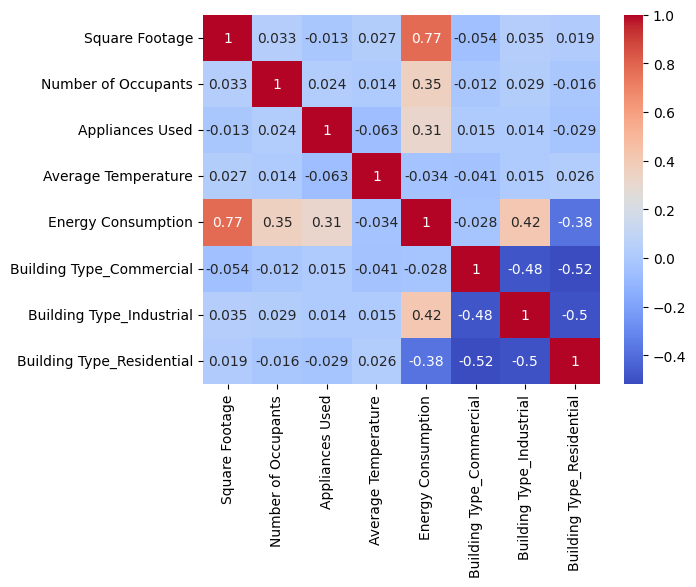

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_train.corr(numeric_only = True)
sns.heatmap(corr, annot=True, cmap='coolwarm')


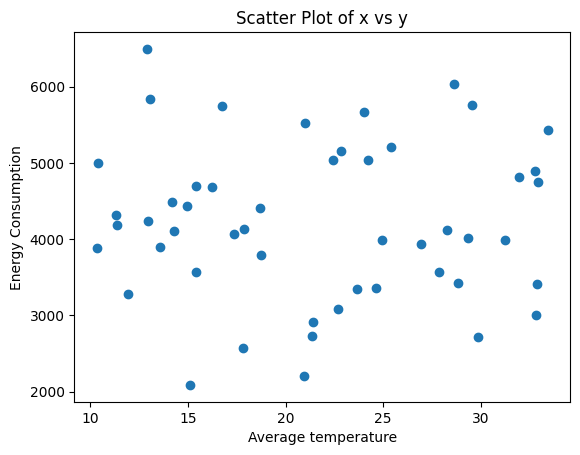

In [6]:
plt.scatter(df_train["Average Temperature"].head(50), df_train["Energy Consumption"].head(50))

plt.xlabel("Average temperature")
plt.ylabel("Energy Consumption")
plt.title("Scatter Plot of x vs y")

plt.show()

In [7]:
# Data Preprocessing #2
# Based on the correlation map and the scatter plots, the fields to be removed are - temperature and day of week
df_train.drop(columns=["Average Temperature", "Day of Week"], inplace=True)
df_test.drop(columns=["Average Temperature", "Day of Week"], inplace=True)
print(df_train)
print()
print()
print(df_test)

     Square Footage  Number of Occupants  Appliances Used  Energy Consumption  \
0              7063                   76               10             2713.95   
1             44372                   66               45             5744.99   
2             19255                   37               17             4101.24   
3             13265                   14               41             3009.14   
4             13375                   26               18             3279.17   
..              ...                  ...              ...                 ...   
995           14419                   68               44             3661.21   
996           12194                    7               22             3546.34   
997           39562                   88               20             5147.21   
998            8348                   67               37             3244.98   
999           15813                   57               11             3423.63   

     Building Type_Commerci

In [8]:
# Data Preprocessing #2 -  Normalization and Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Understanding the range
print(f"Range of occupants in training dataset:  {min(df_train["Number of Occupants"])} - {max(df_train["Number of Occupants"])}.")
print(f"Range of appliances used in training dataset:  {min(df_train["Appliances Used"])} - {max(df_train["Appliances Used"])}.")
print(f"Range of Square footage area in training dataset: {min(df_train["Square Footage"])} - {max(df_train["Square Footage"])}.")

X = df_train.drop("Energy Consumption", axis=1)
y = df_train["Energy Consumption"]
X_test = df_test.drop("Energy Consumption", axis=1)
y_test = df_test["Energy Consumption"]

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=25)

scaler = MinMaxScaler()
X_train[["Number of Occupants", "Appliances Used", "Square Footage"]] = scaler.fit_transform(
    X_train[["Number of Occupants", "Appliances Used", "Square Footage"]])
X_test[["Number of Occupants", "Appliances Used", "Square Footage"]] = scaler.transform(
    X_test[["Number of Occupants", "Appliances Used", "Square Footage"]])
X_valid[["Number of Occupants", "Appliances Used", "Square Footage"]] = scaler.transform(
    X_valid[["Number of Occupants", "Appliances Used", "Square Footage"]])


Range of occupants in training dataset:  1 - 99.
Range of appliances used in training dataset:  1 - 49.
Range of Square footage area in training dataset: 560 - 49997.


In [9]:
# Building the neural network
import tensorflow as tf


model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer = optimizer, loss='mape', metrics=['mape'])
history = model.fit(X_train, y_train, epochs=50, batch_size=15, validation_data=(X_valid, y_valid))

Epoch 1/50


2026-10-01 15:17:07.872693: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 99.9134 - mape: 99.9134 - val_loss: 99.6898 - val_mape: 99.6898
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 98.3968 - mape: 98.3968 - val_loss: 95.4853 - val_mape: 95.4853
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 86.0878 - mape: 86.0878 - val_loss: 69.5204 - val_mape: 69.5204
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 38.1842 - mape: 38.1842 - val_loss: 11.0879 - val_mape: 11.0879
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10.9619 - mape: 10.9619 - val_loss: 7.9222 - val_mape: 7.9222
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.3672 - mape: 8.3672 - val_loss: 6.2174 - val_mape: 6.2174
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.2500 - mape: 7.2500 - val_loss: 5.0459 - val_mape: 5.0459
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.3694 - mape: 6.3694 - val_loss: 3.8013 - val_mape: 3.8013
Epoch 9/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

In [10]:
mape = history.history['mape'][-1]
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Training vs Testing mape:  {mape} to {test_acc}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9968 - mape: 0.9968  
Training vs Testing mape:  4.861212253570557 to 0.9968430399894714


In [11]:
from sklearn.metrics import mean_absolute_percentage_error

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_mape = mean_absolute_percentage_error(y_train, train_pred) * 100
test_mape = mean_absolute_percentage_error(y_test, test_pred) * 100

print("Training MAPE:", train_mape)
print("Testing MAPE:", test_mape)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Training MAPE: 1.015772893171558
Testing MAPE: 0.99684287295514
